In [9]:
import numpy as np
from scipy.stats import norm

# --- HELPER FUNCTIONS ---
def sigmoid(x):
    # Numerically stable sigmoid function
    # If x >= 0: 1 / (1 + exp(-x))
    # If x < 0:  exp(x) / (1 + exp(x))
    return np.where(x >= 0, 
                    1 / (1 + np.exp(-np.clip(x, -500, 500))), 
                    np.exp(np.clip(x, -500, 500)) / (1 + np.exp(np.clip(x, -500, 500))))

class ContextualBanditEnv:
    def __init__(self, num_arms=2, mu_prior=0.0, sigma_env=1.0, sigma_listener=1.0, alpha_trust=0.2, initial_trust=0.5):
        self.num_arms = num_arms
        self.mu_prior = mu_prior
        self.sigma_env = sigma_env
        self.sigma_listener = sigma_listener
        self.alpha_trust = alpha_trust
        
        # --- ROBUST TRUST INITIALIZATION ---
        # We store trust as Logits (Log-Odds) to allow for Bayesian updating.
        # Logit 0.0 corresponds to Probability 0.5 (Neutral).
        safe_trust = np.clip(initial_trust, 0.001, 0.999)
        self.trust_logits = np.log(safe_trust / (1.0 - safe_trust))
        self.trust = initial_trust
        
        # State variables
        self.true_rewards = None
        self.listener_obs = None 
        
    def reset(self):
        """
        Generates a NEW round with fresh rewards and observations.
        """
        # 1. Generate True Rewards
        self.true_rewards = np.random.normal(self.mu_prior, self.sigma_env, self.num_arms)
        
        # 2. Generate Listener Observations (Noisy)
        # Listener gets a noisy signal centered on the True Reward.
        noisy_means = self.true_rewards + np.random.normal(0, self.sigma_listener, self.num_arms)
        
        self.listener_obs = []
        for mu in noisy_means:
            self.listener_obs.append( (mu, self.sigma_listener) )
            
        return self.listener_obs

    def _get_social_belief_params(self, utterance):
        mus = np.array([u[0] for u in utterance])
        sigmas = np.array([u[1] for u in utterance])
        return mus, sigmas

    def _get_listener_belief_params(self):
        mus = np.array([o[0] for o in self.listener_obs])
        sigmas = np.array([o[1] for o in self.listener_obs])
        return mus, sigmas

    def get_final_belief_dist(self, utterance):
        """
        Combines beliefs using Geometric Mixture (Product of Gaussians).
        Mathematically equivalent to Inverse Variance Weighting.
        """
        # 1. Get Parameters
        mu_s, sigma_s = self._get_social_belief_params(utterance)
        mu_l, sigma_l = self._get_listener_belief_params()
        
        # 2. Convert to Precision (lambda = 1 / sigma^2)
        # Add epsilon to avoid division by zero
        prec_s = 1.0 / (sigma_s**2 + 1e-6)
        prec_l = 1.0 / (sigma_l**2 + 1e-6)
        
        # 3. Weighted Precision Sum (Trust gates the Speaker's precision)
        prec_final = (self.trust * prec_s) + ((1 - self.trust) * prec_l)
        
        # 4. Precision-Weighted Mean
        numerator = (self.trust * prec_s * mu_s) + ((1 - self.trust) * prec_l * mu_l)
        mu_final = numerator / prec_final
        
        # 5. Convert back to Sigma
        sigma_final = np.sqrt(1.0 / prec_final)
        
        return mu_final, sigma_final
    
    def step(self, utterance, beta_rationality=5.0):
        # 1. Belief Integration (Geometric)
        mu_final, sigma_final = self.get_final_belief_dist(utterance)
        
        # 2. Action Selection (Softmax on Means)
        # No Risk Aversion: We just use the mean (Expected Value)
        exps = np.exp(beta_rationality * (mu_final - np.max(mu_final)))
        probs = exps / np.sum(exps)
        action = np.random.choice(self.num_arms, p=probs)
        
        # 3. Observe Reward
        reward_obtained = self.true_rewards[action]
        
        # 4. Trust Update (Recursive Bayesian Log-Odds)
        self._update_trust_logits(utterance, action, reward_obtained)
        
        return reward_obtained, action, {
            "trust": self.trust,
            "probs": probs,
            "final_means": mu_final,
            "final_sigmas": sigma_final
        }

    def _update_trust_logits(self, utterance, action, observed_reward):
        """
        Updates trust using the Bayes Factor (Evidence Ratio) added to Logits.
        """
        mu_s, sigma_s = utterance[action]
        mu_l, sigma_l = self.listener_obs[action]
        
        # 1. Calculate Scores (Log Likelihoods)
        # "How well did the Speaker explain this data?"
        score_s = norm.logpdf(observed_reward, loc=mu_s, scale=sigma_s + 1e-6)
        
        # "How well did my own Prior explain this data?"
        score_l = norm.logpdf(observed_reward, loc=mu_l, scale=sigma_l + 1e-6)
        
        # 2. Evidence = Difference in Predictive Power
        evidence = score_s - score_l
        
        # 3. Update Logits
        # alpha acts as learning rate / epistemic sensitivity
        self.trust_logits += self.alpha_trust * evidence
        
        # 4. Convert Logits back to Probability (0 to 1) for the next step
        self.trust = sigmoid(self.trust_logits)

In [10]:
import numpy as np
from scipy.stats import norm

def sigmoid(x):
    return np.where(
        x >= 0,
        1 / (1 + np.exp(-np.clip(x, -500, 500))),
        np.exp(np.clip(x, -500, 500)) / (1 + np.exp(np.clip(x, -500, 500)))
    )

class NormalizedTrustBanditEnv(ContextualBanditEnv):
    """
    Identical to ContextualBanditEnv, but with a *normalized*
    trust update based on:
        ΔΛ ∝ Δ(r_obs) - E_Q[Δ(r)]
    """

    def _update_trust_logits(self, utterance, action, observed_reward):
        # --- Extract parameters for chosen arm ---
        mu_s, sigma_s = utterance[action]
        mu_l, sigma_l = self.listener_obs[action]

        tau = self.trust

        # --- Log-likelihood ratio at the observation ---
        delta_obs = (
            0.5 * np.log((sigma_l ** 2) / (sigma_s ** 2))
            - (observed_reward - mu_s) ** 2 / (2 * sigma_s ** 2)
            + (observed_reward - mu_l) ** 2 / (2 * sigma_l ** 2)
        )

        # --- Compute fused belief Q_t ---
        prec_s = 1.0 / (sigma_s ** 2 + 1e-6)
        prec_l = 1.0 / (sigma_l ** 2 + 1e-6)

        prec_q = (1 - tau) * prec_l + tau * prec_s
        sigma_q2 = 1.0 / prec_q
        mu_q = sigma_q2 * (
            (1 - tau) * prec_l * mu_l
            + tau * prec_s * mu_s
        )

        # --- Expected log-likelihood ratio under Q_t ---
        delta_exp = (
            0.5 * np.log((sigma_l ** 2) / (sigma_s ** 2))
            - ((mu_q - mu_s) ** 2 + sigma_q2) / (2 * sigma_s ** 2)
            + ((mu_q - mu_l) ** 2 + sigma_q2) / (2 * sigma_l ** 2)
        )

        # --- Normalized trust update ---
        trust_gradient = delta_obs - delta_exp
        self.trust_logits += self.alpha_trust * trust_gradient
        self.trust = sigmoid(self.trust_logits)


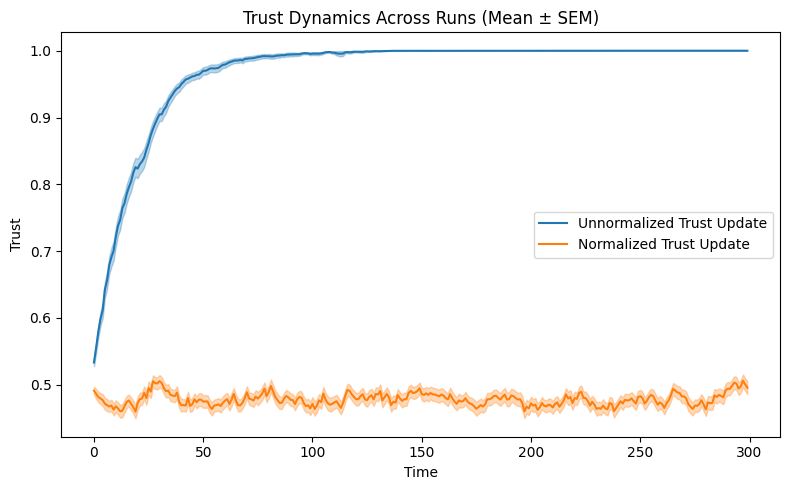

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------
# Experiment parameters
# -----------------------
NUM_RUNS = 200
T = 300
NUM_ARMS = 1

SIGMA_ENV = 0.5
SIGMA_LISTENER = 1.5
SIGMA_SPEAKER = 0.7

ALPHA_TRUST = 0.3
INITIAL_TRUST = 0.5

BETA_RATIONALITY = 1.0  # irrelevant with 1 arm

# -----------------------
# Single-run helper
# -----------------------
def run_single(env_class):
    env = env_class(
        num_arms=NUM_ARMS,
        sigma_env=SIGMA_ENV,
        sigma_listener=SIGMA_LISTENER,
        alpha_trust=ALPHA_TRUST,
        initial_trust=INITIAL_TRUST
    )

    trust_traj = np.zeros(T)

    for t in range(T):
        env.reset()

        # Fixed-quality speaker utterance
        utterance = [(0.8, SIGMA_SPEAKER)]

        _, _, info = env.step(
            utterance,
            beta_rationality=BETA_RATIONALITY
        )

        trust_traj[t] = info["trust"]

    return trust_traj


# -----------------------
# Run multiple simulations
# -----------------------
trust_raw = np.zeros((NUM_RUNS, T))
trust_norm = np.zeros((NUM_RUNS, T))

for i in range(NUM_RUNS):
    trust_raw[i] = run_single(ContextualBanditEnv)
    trust_norm[i] = run_single(NormalizedTrustBanditEnv)

# -----------------------
# Aggregate statistics
# -----------------------
mean_raw = trust_raw.mean(axis=0)
sem_raw = trust_raw.std(axis=0) / np.sqrt(NUM_RUNS)

mean_norm = trust_norm.mean(axis=0)
sem_norm = trust_norm.std(axis=0) / np.sqrt(NUM_RUNS)

# -----------------------
# Plot
# -----------------------
plt.figure(figsize=(8, 5))

plt.plot(mean_raw, label="Unnormalized Trust Update", color="tab:blue")
plt.fill_between(
    np.arange(T),
    mean_raw - sem_raw,
    mean_raw + sem_raw,
    color="tab:blue",
    alpha=0.3
)

plt.plot(mean_norm, label="Normalized Trust Update", color="tab:orange")
plt.fill_between(
    np.arange(T),
    mean_norm - sem_norm,
    mean_norm + sem_norm,
    color="tab:orange",
    alpha=0.3
)

plt.xlabel("Time")
plt.ylabel("Trust")
plt.title("Trust Dynamics Across Runs (Mean ± SEM)")
plt.legend()
plt.tight_layout()
plt.show()


In [23]:
import numpy as np
from scipy.stats import norm

class LogPoolingKalmanTrustBanditEnv(ContextualBanditEnv):
    """
    Trust is an unbounded latent variable Λ_t learned via Kalman filtering.
    Belief fusion uses asymmetric log-opinion pooling:
        Q ∝ P_L * P_S^Λ
    """

    def __init__(
        self,
        *args,
        trust_mean_init=0.0,
        trust_var_init=1.0,
        trust_process_var=0.01,
        trust_obs_var=1.0,
        **kwargs
    ):
        super().__init__(*args, **kwargs)

        # --- Kalman state ---
        self.trust_mean = trust_mean_init
        self.trust_var = trust_var_init

        self.trust_process_var = trust_process_var
        self.trust_obs_var = trust_obs_var

    # ------------------------------------------------------------------
    # Belief fusion via log-opinion pooling
    # ------------------------------------------------------------------
    def get_final_belief_dist(self, utterance):
        mu_s, sigma_s = self._get_social_belief_params(utterance)
        mu_l, sigma_l = self._get_listener_belief_params()

        prec_s = 1.0 / (sigma_s**2 + 1e-6)
        prec_l = 1.0 / (sigma_l**2 + 1e-6)

        Λ = self.trust_mean  # unbounded trust

        prec_q = prec_l + Λ * prec_s
        prec_q = np.clip(prec_q, 1e-6, None)

        mu_q = (prec_l * mu_l + Λ * prec_s * mu_s) / prec_q
        sigma_q = np.sqrt(1.0 / prec_q)

        return mu_q, sigma_q

    # ------------------------------------------------------------------
    # Kalman trust update
    # ------------------------------------------------------------------
    def _update_trust_kalman(self, utterance, action, observed_reward):
        mu_s, sigma_s = utterance[action]
        mu_l, sigma_l = self.listener_obs[action]

        # --- Observation: log likelihood ratio ---
        log_p_s = norm.logpdf(observed_reward, mu_s, sigma_s + 1e-6)
        log_p_l = norm.logpdf(observed_reward, mu_l, sigma_l + 1e-6)
        z = log_p_s - log_p_l

        # --- Kalman prediction ---
        m_pred = self.trust_mean
        P_pred = self.trust_var + self.trust_process_var

        # --- Kalman update ---
        S = P_pred + self.trust_obs_var
        K = P_pred / S

        self.trust_mean = m_pred + K * (z - m_pred)
        self.trust_var = (1 - K) * P_pred

    # ------------------------------------------------------------------
    # Step override (only trust update changes)
    # ------------------------------------------------------------------
    def step(self, utterance, beta_rationality=5.0):
        mu_final, sigma_final = self.get_final_belief_dist(utterance)

        exps = np.exp(beta_rationality * (mu_final - np.max(mu_final)))
        probs = exps / np.sum(exps)
        action = np.random.choice(self.num_arms, p=probs)

        reward_obtained = self.true_rewards[action]

        self._update_trust_kalman(utterance, action, reward_obtained)

        return reward_obtained, action, {
            "trust_mean": self.trust_mean,
            "trust_var": self.trust_var,
            "probs": probs,
            "final_means": mu_final,
            "final_sigmas": sigma_final
        }


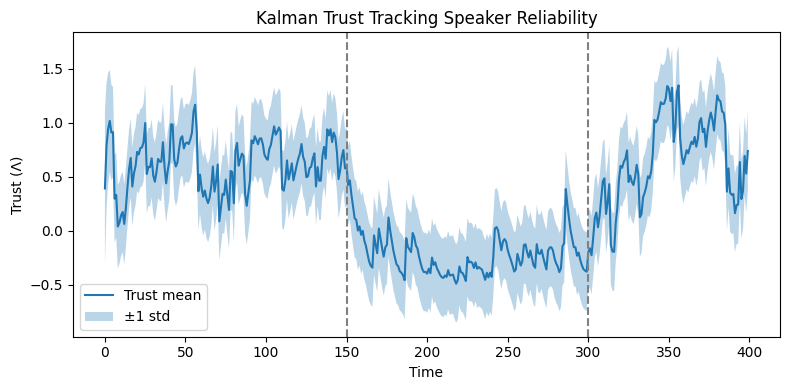

In [43]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------
# Parameters
# -----------------------
T = 400
SWITCH_1 = 150
SWITCH_2 = 300

NUM_ARMS = 1
SIGMA_ENV = 0.5
SIGMA_LISTENER = 1.2

SIGMA_SPEAKER_GOOD = 0.4
SIGMA_SPEAKER_BAD = 2.5

# -----------------------
# Environment
# -----------------------
env = LogPoolingKalmanTrustBanditEnv(
    num_arms=NUM_ARMS,
    sigma_env=SIGMA_ENV,
    sigma_listener=SIGMA_LISTENER,
    trust_mean_init=0.0,
    trust_var_init=1.0,
    trust_process_var=0.02,
    trust_obs_var=1.0
)

trust_means = []
trust_vars = []

# -----------------------
# Run
# -----------------------
for t in range(T):
    env.reset()

    # Regime switching speaker
    if t < SWITCH_1:
        sigma_s = SIGMA_SPEAKER_GOOD
    elif t < SWITCH_2:
        sigma_s = SIGMA_SPEAKER_BAD
    else:
        sigma_s = SIGMA_SPEAKER_GOOD

    utterance = [(0.0, sigma_s)]

    _, _, info = env.step(utterance)

    trust_means.append(info["trust_mean"])
    trust_vars.append(info["trust_var"])

# -----------------------
# Plot
# -----------------------
plt.figure(figsize=(8, 4))
plt.plot(trust_means, label="Trust mean")
plt.fill_between(
    np.arange(T),
    np.array(trust_means) - np.sqrt(trust_vars),
    np.array(trust_means) + np.sqrt(trust_vars),
    alpha=0.3,
    label="±1 std"
)

plt.axvline(SWITCH_1, linestyle="--", color="gray")
plt.axvline(SWITCH_2, linestyle="--", color="gray")

plt.xlabel("Time")
plt.ylabel("Trust (Λ)")
plt.title("Kalman Trust Tracking Speaker Reliability")
plt.legend()
plt.tight_layout()
plt.show()


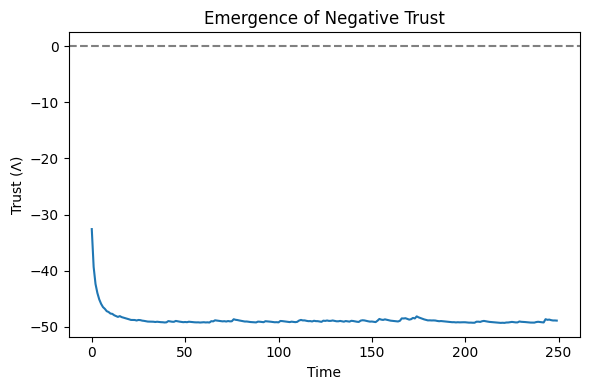

In [52]:
T = 250

env = LogPoolingKalmanTrustBanditEnv(
    num_arms=1,
    sigma_env=0.3,
    sigma_listener=0.5,
    trust_mean_init=0.0,
    trust_var_init=1.0,
    trust_process_var=0.01,
    trust_obs_var=0.5
)

trust_means = []

for t in range(T):
    env.reset()

    # Speaker is confidently wrong
    true_mu = env.true_rewards[0]
    utterance = [(true_mu + 3.0, 0.3)]  # biased and confident

    _, _, info = env.step(utterance)
    trust_means.append(info["trust_mean"])

plt.figure(figsize=(6, 4))
plt.plot(trust_means)
plt.axhline(0, linestyle="--", color="gray")
plt.xlabel("Time")
plt.ylabel("Trust (Λ)")
plt.title("Emergence of Negative Trust")
plt.tight_layout()
plt.show()


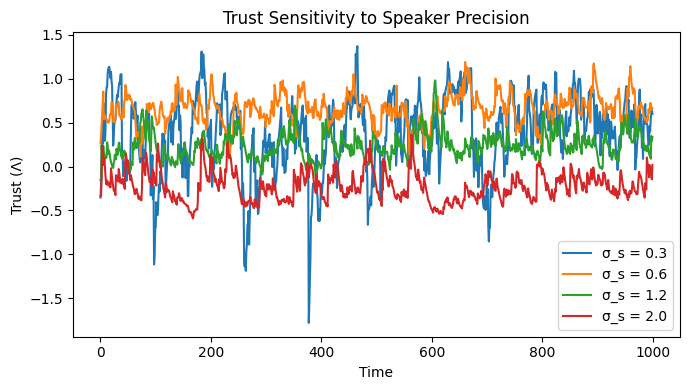

In [61]:
T = 1000
SIGMAS = [0.3, 0.6, 1.2, 2.0]

plt.figure(figsize=(7, 4))

for sigma_s in SIGMAS:
    env = LogPoolingKalmanTrustBanditEnv(
        num_arms=1,
        sigma_env=0.5,
        sigma_listener=1.0,
        trust_process_var=0.01,
        trust_obs_var=1.0
    )

    trusts = []

    for _ in range(T):
        env.reset()
        utterance = [(0.0, sigma_s)]
        _, _, info = env.step(utterance)
        trusts.append(info["trust_mean"])

    plt.plot(trusts, label=f"σ_s = {sigma_s}")

plt.xlabel("Time")
plt.ylabel("Trust (Λ)")
plt.title("Trust Sensitivity to Speaker Precision")
plt.legend()
plt.tight_layout()
plt.show()


In [70]:
import itertools

def gaussian_kl(mu_p, sigma_p, mu_q, sigma_q):
    sigma_p = np.maximum(sigma_p, 1e-6)
    sigma_q = np.maximum(sigma_q, 1e-6)
    return np.log(sigma_q / sigma_p) + (sigma_p**2 + (mu_p - mu_q)**2) / (2 * sigma_q**2) - 0.5

def get_asymmetric_log_pool(mu_l, sigma_l, mu_s, sigma_s, Lambda):
    """
    Q ∝ P_L * P_S^Lambda
    """
    prec_l = 1.0 / (sigma_l**2 + 1e-6)
    prec_s = 1.0 / (sigma_s**2 + 1e-6)

    prec_q = prec_l + Lambda * prec_s
    prec_q = max(prec_q, 1e-6)

    mu_q = (prec_l * mu_l + Lambda * prec_s * mu_s) / prec_q
    sigma_q = np.sqrt(1.0 / prec_q)

    return mu_q, sigma_q



class RollingHorizonSpeaker:
    def __init__(self, num_arms=2, horizon=2, gamma_honesty=1.0, 
                 beta_listener=5.0, beta_speaker=5.0,
                 msg_means=None, msg_vars=None):
        self.num_arms = num_arms
        self.horizon = horizon
        self.gamma = gamma_honesty
        self.beta_listener = beta_listener
        self.beta_speaker = beta_speaker
        
        # Build Discretized Action Space
        self.means = msg_means if msg_means else [-5.0, 0.0, 5.0]
        self.vars = msg_vars if msg_vars else [0.1, 5.0]        
        base = list(itertools.product(self.means, self.vars))
        self.utterance_space = list(itertools.product(base, repeat=self.num_arms))

    def _kalman_update(self, m, P, z, process_var=0.0, obs_var=1.0):
        """
        Single Kalman update for trust.
        """
        # Prediction
        m_pred = m
        P_pred = P + process_var

        # Update
        S = P_pred + obs_var
        K = P_pred / S

        m_new = m_pred + K * (z - m_pred)
        P_new = (1 - K) * P_pred

        return m_new, P_new


    def get_policy_distribution(self, current_trust_state, obs_L_seq, obs_S_truth_seq, obs_S_incentive_seq, process_var=0.0, obs_var=1.0):
        """
        Calculates the softmax policy distribution over all possible utterances.
        """
        trust_mean = current_trust_state

        
        # Ensure we don't look past the end of the game
        eff_horizon = min(self.horizon, len(obs_L_seq))
        
        q_values = []
        for u in self.utterance_space:
            # Full Recursive Evaluation
            q_val = self._evaluate_action(
                u, current_trust_state, obs_L_seq, obs_S_truth_seq, obs_S_incentive_seq, 
                depth=eff_horizon, step_idx=0, process_var=0.0, obs_var=1.0
            )
            q_values.append(q_val)
            
        q_values = np.array(q_values)
        
        # Apply Softmax (Boltzmann Policy)
        # Shift q_values for numerical stability
        exps = np.exp(self.beta_speaker * (q_values - np.max(q_values)))
        probs = exps / np.sum(exps)
        
        return self.utterance_space, probs

    def _evaluate_action(self, u, trust_state, obs_L_seq, obs_S_truth_seq, obs_S_incentive_seq, depth, step_idx, process_var=0.0, obs_var=1.0):
        """
        Recursive Soft-Bellman Equation:
        Q(s, u) = Immediate_Reward + Expected_Value_Next_State
        """
        trust_mean, trust_var = trust_state
        tr_mean = trust_mean

        curr_L_prior = obs_L_seq[step_idx]
        curr_S_truth = obs_S_truth_seq[step_idx]
        curr_S_inc   = obs_S_incentive_seq[step_idx]

        # --- A. SIMULATE LISTENER BELIEF UPDATE ---
        new_beliefs_L = []
        kl_cost = 0.0
        
        for i in range(self.num_arms):
            mu_u, sig_u = u[i]
            mu_prior, sig_prior = curr_L_prior[i]
            
            # Geometric Pooling (Trust-weighted update)
            mu_new, sig_new = get_asymmetric_log_pool(
                mu_l=mu_prior,
                sigma_l=sig_prior,
                mu_s=mu_u,
                sigma_s=sig_u,
                Lambda=tr_mean
            )

            new_beliefs_L.append((mu_new, sig_new))
            
            # Global Honesty Cost (Sum over ALL arms)
            mu_true, sig_true = curr_S_truth[i]
            kl_cost += gaussian_kl(mu_true, sig_true, mu_new, sig_new)
        
        utility_info = -kl_cost

        # --- B. SIMULATE LISTENER DECISION ---
        means_new = np.array([b[0] for b in new_beliefs_L])
        # Listener chooses based on their new belief means
        exps = np.exp(self.beta_listener * (means_new - np.max(means_new)))
        probs_L = exps / np.sum(exps)
        
        # --- C. IMMEDIATE REWARD (Instrumental) ---
        incentive_values = np.array([o[0] for o in curr_S_inc])
        utility_extrinsic = np.sum(probs_L * incentive_values)
        
        immediate_utility = utility_extrinsic + (self.gamma * utility_info)

        # --- D. FUTURE VALUE (Recursion) ---
        future_value_expected = 0.0
        
        # Only recurse if we have horizon left AND data left
        if depth > 1 and (step_idx + 1) < len(obs_L_seq):
            
            # Expectation over Listener's Action
            for action_idx in range(self.num_arms):
                prob_action = probs_L[action_idx]
                
                # Optimization: Skip negligible branches
                if prob_action < 0.001: continue 
                
                # --- TRUST UPDATE (Verification Bottleneck) ---
                # Listener observes truth ONLY for action_idx
                predicted_observation = curr_S_truth[action_idx][0]
                
                mu_s_msg, sig_s_msg = u[action_idx]
                mu_l_prior, sig_l_prior = curr_L_prior[action_idx]
                
                # Calculate Evidence (Log Likelihood Ratio)
                score_s = norm.logpdf(predicted_observation, loc=mu_s_msg, scale=sig_s_msg + 1e-6)
                score_l = norm.logpdf(predicted_observation, loc=mu_l_prior, scale=sig_l_prior + 1e-6)
                
                z = score_s - score_l

                new_trust_mean, new_trust_var = self._kalman_update(
                    trust_mean,
                    trust_var,
                    z,
                    process_var=0.0,       # listener assumed stationary
                    obs_var=1.0            # match env.trust_obs_var
                )

                new_trust_state = (new_trust_mean, new_trust_var)

                
                # Recursively calculate Value of the next state V(s')
                val_future = self._get_state_value_soft(
                    new_trust_state, obs_L_seq, obs_S_truth_seq, obs_S_incentive_seq, 
                    depth - 1, step_idx + 1
                )
                
                future_value_expected += prob_action * val_future

        return immediate_utility + future_value_expected

    def _get_state_value_soft(self, trust_state, obs_L_seq, obs_S_truth_seq, obs_S_incentive_seq, depth, step_idx):
        """
        Calculates V(s) = SoftMax_u( Q(s, u) )
        """
        if depth == 0 or step_idx >= len(obs_L_seq):
            return 0.0
            
        q_values = []
        for u in self.utterance_space:
            val = self._evaluate_action(
                u, trust_state, obs_L_seq, obs_S_truth_seq, obs_S_incentive_seq, 
                depth, step_idx
            )
            q_values.append(val)
        
        q_values = np.array(q_values)
        
        # LogSumExp for Soft Value
        beta = self.beta_speaker
        max_q = np.max(q_values)
        soft_value = max_q + (1.0 / beta) * np.log(np.sum(np.exp(beta * (q_values - max_q))))
        
        return soft_value

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

def plot_strategy_comparison(df_myopic, df_strategic, alpha_val):
    """
    Generates 3 heatmaps: Myopic, Strategic, and the Difference.
    Includes the Alpha Value in the title for clear comparison.
    """
    # Setup Figure
    fig, axes = plt.subplots(1, 3, figsize=(24, 7))
    plt.subplots_adjust(wspace=0.3)
    
    # Common Args for Heatmaps
    heatmap_args = {
        "annot": True, 
        "fmt": ".2f", 
        "cmap": "Greens", 
        "vmin": 0.0, 
        "vmax": max(df_myopic.max().max(), df_strategic.max().max()), # Scale to global max
        "cbar": False,
        "square": True,
        "linewidths": 0.5,
        "linecolor": "gray"
    }

    # 1. Myopic Plot (Baseline)
    sns.heatmap(df_myopic, ax=axes[0], **heatmap_args)
    axes[0].set_title(f"Myopic Policy (H=1)\nGreedy Deception", fontsize=14, fontweight='bold', pad=15)
    axes[0].set_xlabel("Alternative Arm Message", fontsize=12)
    axes[0].set_ylabel("Target Arm Message", fontsize=12)

    # 2. Strategic Plot (Planning)
    sns.heatmap(df_strategic, ax=axes[1], **heatmap_args)
    axes[1].set_title(f"Strategic Policy (H=2)\nCalculated Manipulation", fontsize=14, fontweight='bold', pad=15)
    axes[1].set_xlabel("Alternative Arm Message", fontsize=12)
    axes[1].set_yticks([]) # Hide y-labels

    # 3. Difference Plot (The Shift)
    df_diff = df_strategic - df_myopic
    
    # Use diverging colormap (Red=Increase, Blue=Decrease)
    limit = max(abs(df_diff.min().min()), abs(df_diff.max().max()))
    sns.heatmap(df_diff, ax=axes[2], annot=True, fmt=".2f", 
                cmap="coolwarm", center=0.0, vmin=-limit, vmax=limit,
                square=True, linewidths=0.5, linecolor="gray", cbar=True)
    
    axes[2].set_title(f"Strategic Shift (Strat - Myopic)\nRed = Adopted, Blue = Abandoned", fontsize=14, fontweight='bold', pad=15)
    axes[2].set_xlabel("Alternative Arm Message", fontsize=12)
    axes[2].set_yticks([]) 

    # Clean up labels (rotate for readability)
    for ax in axes:
        plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
        plt.setp(ax.get_yticklabels(), rotation=0)

    # Main Title with Alpha
    title_str = f"Verification Gap (Alpha = {alpha_val})"
        
    plt.suptitle(title_str, fontsize=20, y=1.05)
    
    return fig

--- RUNNING EXPERIMENT ---
Current Incentives: [10.0, -10.0]
Future Incentives:  [10.0, 0.0]
Computing Myopic Policy...
Computing Strategic Policy...


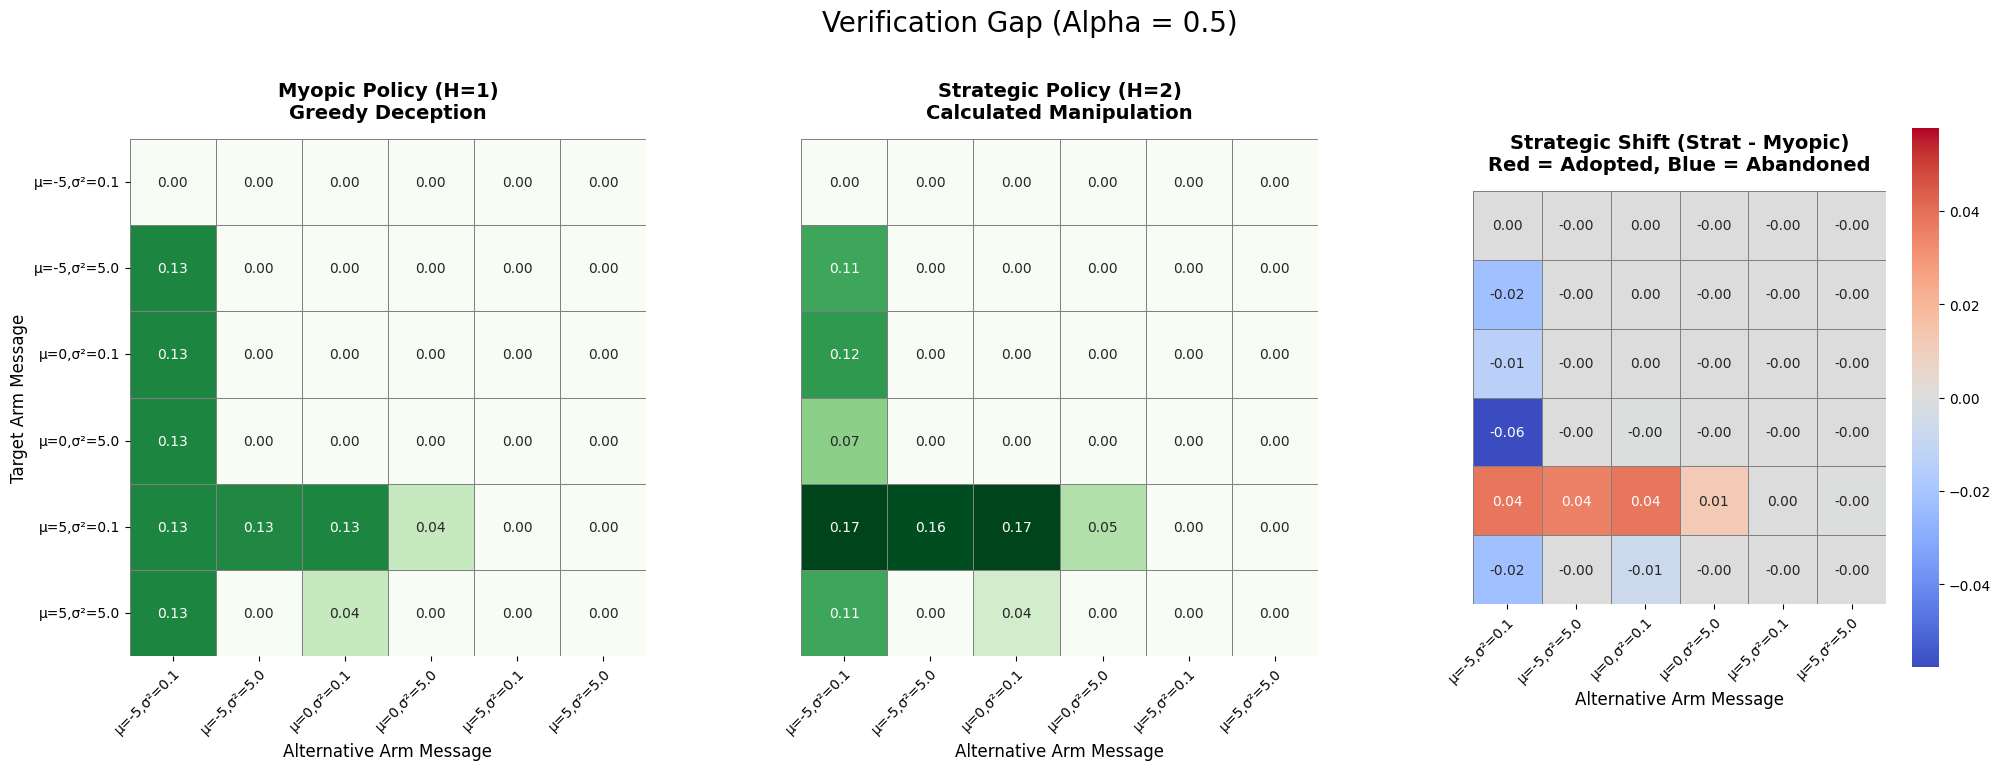

In [ ]:
import pandas as pd
import itertools

# ==========================================
# 1. EXPERIMENT PARAMETERS (Edit Here)
# ==========================================
# --- Agent Settings ---
HORIZON_MYOPIC    = 1      # Baseline (Greedy)
HORIZON_STRATEGIC = 2      # Planning (Sees Step 2)
GAMMA_HONESTY     = 0.0    # Low cost of lying
ALPHA_TRUST       = 0.5    # Learning rate for trust updates
BETA_SPEAKER      = 3.0    # Rationality
BETA_LISTENER     = 3.0    # Decision sharpness

# --- Action Space ---
MSG_MEANS = [-5.0, 0.0, 5.0]
MSG_VARS  = [0.1, 5.0]

# --- STEP 1: CURRENT STATE (The conflict right now) ---
# Target Arm (0): Truth=0.0 (Bad), Incentive=10.0 (High) -> Speaker wants to trick Listener
# Alt Arm (1):    Truth=5.0 (Good), Incentive=-10.0 (Penalty) -> Speaker avoids Good arm
CURR_TRUTH      = [0.0, 5.0]
CURR_INCENTIVES = [10.0, -10.0] 

# Listener Prior (Accurate Means but Unsure)
L_PRIOR_MEANS   = [0.0, 5.0]
L_PRIOR_VARS    = [3.0, 3.0] 
START_TRUST     = (1.0, 1.0)
PROCESS_VAR    = 0.001
OBS_VAR        = 1.0

# --- STEP 2+: FUTURE SIMULATION (What happens next?) ---
# You can change these to test if the agent anticipates a changing world.
# currently set to match current state (static world)
FUTURE_TRUTH      = [0.0, 5.0]  
FUTURE_INCENTIVES = [10.0, 0.0] # Agent expects same conflict in future

# ==========================================
# 2. RUN EXPERIMENT
# ==========================================
def run_notebook_experiment():
    print(f"--- RUNNING EXPERIMENT ---")
    print(f"Current Incentives: {CURR_INCENTIVES}")
    print(f"Future Incentives:  {FUTURE_INCENTIVES}")
    
    # 1. Construct Simulation Sequences (History + Future)
    # We construct the observation sequences explicitly step-by-step
    obs_L = []
    obs_S_truth = []
    obs_S_inc = []
    
    # Step 0 (Current)
    obs_L.append([(m, v) for m, v in zip(L_PRIOR_MEANS, L_PRIOR_VARS)])
    obs_S_truth.append([(v, 0.1) for v in CURR_TRUTH])
    obs_S_inc.append([(v, 0.1) for v in CURR_INCENTIVES])
    
    # Step 1...H (Future/Simulation) - extending for horizon
    for _ in range(3): 
        # In simulation, we assume Listener carries over belief, but for the 
        # 'environment' params, we use the FUTURE settings defined above.
        obs_L.append([(m, v) for m, v in zip(L_PRIOR_MEANS, L_PRIOR_VARS)]) 
        obs_S_truth.append([(v, 0.1) for v in FUTURE_TRUTH])
        obs_S_inc.append([(v, 0.1) for v in FUTURE_INCENTIVES])

    # 2. Instantiate Agents
    s_myopic = RollingHorizonSpeaker(
        num_arms=2, horizon=HORIZON_MYOPIC, 
        gamma_honesty=GAMMA_HONESTY, 
        beta_speaker=BETA_SPEAKER, beta_listener=BETA_LISTENER,
        msg_means=MSG_MEANS, msg_vars=MSG_VARS
    )
    
    s_strat = RollingHorizonSpeaker(
        num_arms=2, horizon=HORIZON_STRATEGIC, 
        gamma_honesty=GAMMA_HONESTY, 
        beta_speaker=BETA_SPEAKER, beta_listener=BETA_LISTENER,
        msg_means=MSG_MEANS, msg_vars=MSG_VARS
    )

    # 3. Compute Policies
    print("Computing Myopic Policy...")
    space, probs_m = s_myopic.get_policy_distribution(START_TRUST, obs_L, obs_S_truth, obs_S_inc, process_var=PROCESS_VAR, obs_var=OBS_VAR)
    
    print("Computing Strategic Policy...")
    _, probs_s = s_strat.get_policy_distribution(START_TRUST, obs_L, obs_S_truth, obs_S_inc, process_var=PROCESS_VAR, obs_var=OBS_VAR)

    # 4. Visualize as 2D Matrix
    def display_matrix(probs, title):
        # Create labels based on Message Space
        base = list(itertools.product(MSG_MEANS, MSG_VARS))
        labels = [f"µ={m:.0f},σ²={v:.1f}" for m, v in base]
        
        df = pd.DataFrame(0.0, index=labels, columns=labels)
        
        for k, u in enumerate(space):
            u_t, u_a = u[0], u[1]
            row_lbl = f"µ={u_t[0]:.0f},σ²={u_t[1]:.1f}"
            col_lbl = f"µ={u_a[0]:.0f},σ²={u_a[1]:.1f}"
            df.at[row_lbl, col_lbl] = probs[k]
            
        print(f"\n>>> {title} <<<")
        print("Rows = Target Msg | Cols = Alt Msg")
        display(df) # Using display() for nice Jupyter formatting
        return df

    # Display settings
    pd.set_option('display.float_format', '{:.3f}'.format)
    
    #df_m = display_matrix(probs_m, f"MYOPIC (H={HORIZON_MYOPIC})")
    #df_s = display_matrix(probs_s, f"STRATEGIC (H={HORIZON_STRATEGIC})")
    
    #print(f"\n>>> STRATEGIC SHIFT (Strategic - Myopic) <<<")
    #display(df_s - df_m)
    
        # Helper to make DF
    def to_df(probs):
        base = list(itertools.product(MSG_MEANS, MSG_VARS))
        labels = [f"µ={m:.0f},σ²={v:.1f}" for m, v in base]
        df = pd.DataFrame(0.0, index=labels, columns=labels)
        for k, u in enumerate(space):
            u_t, u_a = u[0], u[1]
            row = f"µ={u_t[0]:.0f},σ²={u_t[1]:.1f}"
            col = f"µ={u_a[0]:.0f},σ²={u_a[1]:.1f}"
            df.at[row, col] = probs[k]
        return df

    return to_df(probs_m), to_df(probs_s)

df_m, df_s = run_notebook_experiment()

# 2. Plot
fig = plot_strategy_comparison(df_m, df_s, ALPHA_TRUST)
plt.show()